<a href="https://colab.research.google.com/github/irungus/Applied-Machine-Learning/blob/main/POA%20CAT%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

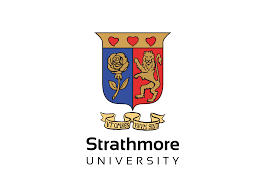


<center>
<h1> </h1>
<h2>PREDICTIVE OPTIMIZATION ANALYTICS CAT 1</h2>
<h3>Samuel Irungu Kigotho</h3>
<h4>Adm No: 169124</h4>
</center>

#Vehicle Insurance Fraud Detection <br>
Vehicle insurance fraud involves conspiring to file false or exaggerated claims related to property
damage or personal injuries following an accident. Common examples include staged accidents,
where fraudsters deliberately "orchestrate" collisions; the use of phantom passengers, where
individuals do not present at the accident scene falsely claim to have suffered severe injuries; and
exaggerated personal injury claims, where minor injuries are portrayed as serious to maximize
compensation.
You have been assigned the task of developing a predictive model optimized to identify potential
fraudulent cases.  [link text](https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Insurance%20Fraud%20data.csv) <br>

NB. Use F1_score to evaluate your performance across all models or Alternative Use
Smote to sort the class imbalance then use Accuracy, which ever choice of your metrics
ensure consistency across the work.


# Importing Relevant Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Importing the Dataset

In [8]:
#import dataset
url = "https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Insurance%20Fraud%20data.csv"


In [9]:
data = pd.read_csv(url)

# Step 1: Data Preprocessing
Prepare your dataset for modeling by performing the following tasks. For each step you decide
to use, provide comments and explanations for your choices and outputs:


# Data Cleaning
➢ Handle missing values, duplicates, or outliers. <br>
➢ Remove or impute missing data and identify inconsistencies in your dataset.

# Initial Data Exploration

In [13]:
#Getting a feel of the data by looking at the first 5 rows of the dataset
data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [14]:
# Observing the statistical characteristics of the dataset
data.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [15]:
#Check if there are any null values in the dataset
data.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


Clearly  There are no null values

In [17]:
# Check for the number of rows and columns in the dataset
data.shape

(15420, 33)

# Initial data cleaning and wrangling
## Detecting and removing duplicates
Duplicate rows, if exists, will be removed

In [18]:
# To find out if there are duplicated records across all columns
data[data.duplicated(keep='first')]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy


In [19]:
# Number of rows remain the same at 15420, no duplicates present and dropped
data.drop_duplicates ()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,...,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,...,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,...,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


We check for cardinality which refers to the number of unique values in a dataset column. It helps determine whether a column has low, medium, or high uniqueness among its values.

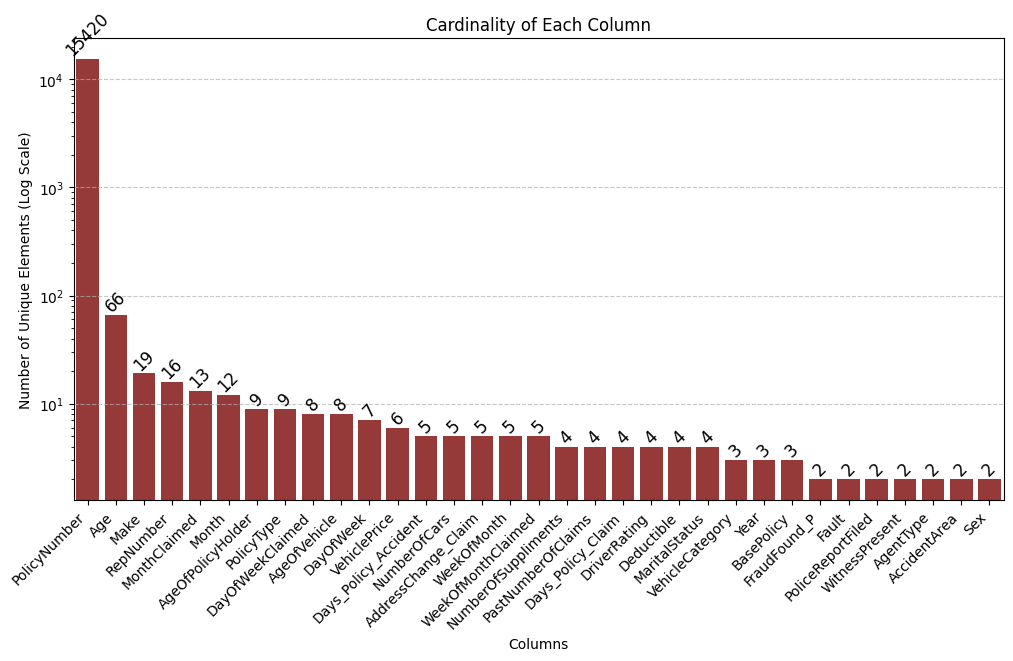

In [31]:
# check for cardinality
# Compute cardinality
cardinality = {col: data[col].nunique() for col in data.select_dtypes(include=['object', 'int64', 'float64']).columns}

# Convert to DataFrame
cardinality_df = pd.DataFrame(cardinality.items(), columns=['Column', 'Unique Values'])

# Sort by cardinality
cardinality_df = cardinality_df.sort_values(by="Unique Values", ascending=False)

# Plot the cardinality
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Column', y='Unique Values', data=cardinality_df, color='brown')
plt.xlabel('Columns')
plt.ylabel('Number of Unique Elements')
plt.yscale("log")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Columns")
plt.ylabel("Number of Unique Elements (Log Scale)")
plt.title("Cardinality of Each Column")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', rotation=45)

plt.show()

I want to get the value counts of all the features for a more in-depth analysis and plot them

In [50]:
# Get the value counts of all the features for a more in-depth analysis
columns= data.columns
for col in columns:
    print(data[col].value_counts())

Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64
WeekOfMonth
3    3640
2    3558
4    3398
1    3187
5    1637
Name: count, dtype: int64
DayOfWeek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64
Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64
AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64
DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday 

## Clean up columns - DayOfWeekClaimed and MonthClaimed
There is a row with 0 for both DayOfWeekClaimed and MonthClaimed

In [54]:
data.loc[(data['MonthClaimed'] == '0') & (data['DayOfWeekClaimed'] == '0')]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils


It seems that this is under 1516 row hence we drop it

In [55]:
# Drop the row 1516
data.drop(1516, axis = 0, inplace = True)

# Reset index of the dataset after dropping row
data.reset_index(drop= True, inplace = True)

Remove unncessary column - PolicyNumber as they are all unique

In [56]:
data.drop('PolicyNumber', axis = 1, inplace = True)

In [58]:
data.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,RepNumber,Deductible,DriverRating,Year
count,15419.000000,15419.000000,15419.000000,15419.000000,15419.000000,15419.000000,15419.000000,15419.000000
mean,2.788637,2.694079,39.858292,0.059861,8.482846,407.704780,2.487840,1994.866528
std,1.287611,1.259082,13.488996,0.237237,4.599798,43.952379,1.119482,0.803309
min,1.000000,1.000000,0.000000,0.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,16.000000,700.000000,4.000000,1996.000000


There is an age that is 0 lets explore more on age

In [60]:
# Dive in deeper into age to look at the unique categories , realised that there is age 0 - which is illogical
data['Age'].unique()

array([21, 34, 47, 65, 27, 20, 36,  0, 30, 42, 71, 52, 28, 61, 38, 41, 32,
       40, 63, 31, 45, 60, 39, 55, 35, 44, 72, 29, 37, 59, 49, 50, 26, 48,
       64, 33, 74, 23, 25, 56, 16, 68, 18, 51, 22, 53, 46, 43, 57, 54, 69,
       67, 19, 78, 77, 75, 80, 58, 73, 24, 76, 62, 79, 70, 17, 66])

Lets check how many

In [61]:
# There a total of 319 rows with age = 0
data[data['Age'] ==0]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
13,Jan,5,Friday,Honda,Rural,Wednesday,Feb,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
28,Jul,1,Saturday,Honda,Urban,Tuesday,Sep,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils
31,Mar,1,Sunday,Honda,Urban,Tuesday,Mar,2,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
58,May,1,Monday,Honda,Rural,Wednesday,May,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Liability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15242,May,2,Tuesday,Honda,Urban,Monday,May,3,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15261,Mar,3,Monday,Honda,Urban,Thursday,Mar,3,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15273,Apr,3,Monday,Honda,Urban,Tuesday,May,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Collision
15378,Jan,2,Tuesday,Honda,Urban,Thursday,Jan,2,Male,Single,...,new,16 to 17,No,No,External,none,1 year,1 vehicle,1996,All Perils


Lets impute using the mean of the age

In [62]:
# Find the mean of the Age column
mn = round(data['Age'].mean(), 0)
# Replace all 0 values woth the average age
data.loc[data['Age']==0, 'Age'] = mn

# Exploratory Data Analysis

In [65]:
# Check for columns in dataset
data.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'RepNumber', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [69]:
# Group the categorical features and continuous features separately
categorical = []
continuous = []
for col in data.columns:
    if len(data[col].unique()) < 20:   # if the unque values of a feature is more than 20, group it as a categorical feature
        categorical.append(col)
    else:
        continuous.append(col)

print(categorical)
print(continuous)

['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
['Age']


Only Age is continous others are categorical

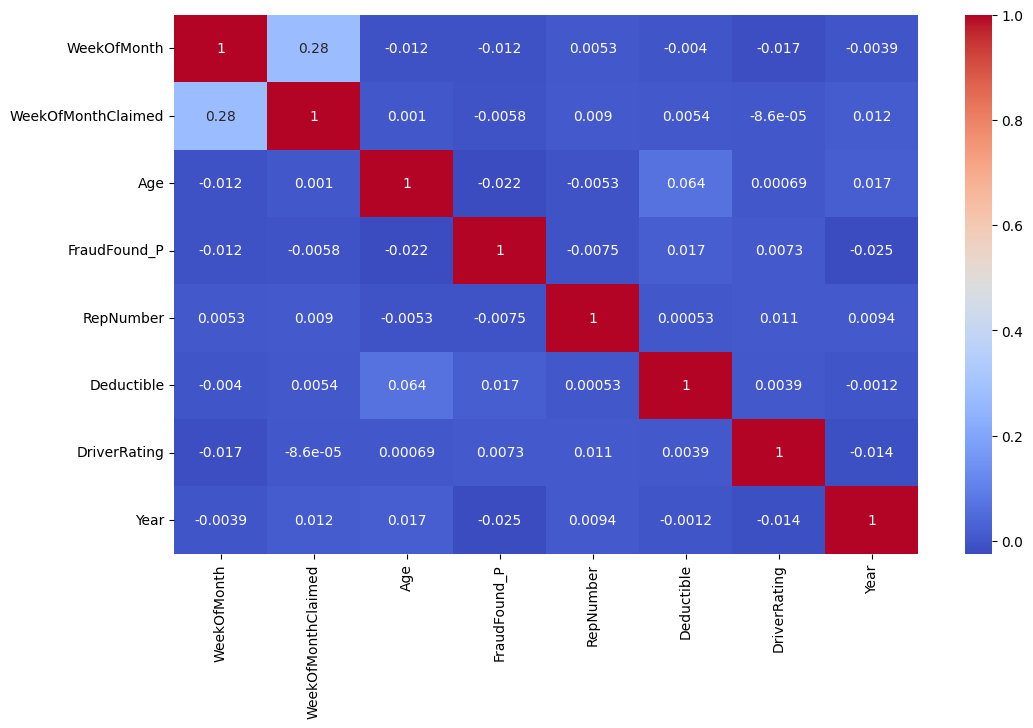

In [71]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Create the heatmap using only the numeric columns
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=True, ax=ax)
plt.show()

There is no strong correlation within the features , thus there is no multicollinearity. This is also due to the fact that there is only 1 continuous feature - Age.

## Continuous Features
The only continuous feature in this dataset is Age. Thus, we will look at the distribution of Age and how it influences the fraud cases.

[Text(0.5, 1.0, 'Histogram of Age'), Text(0.5, 0, 'Age')]

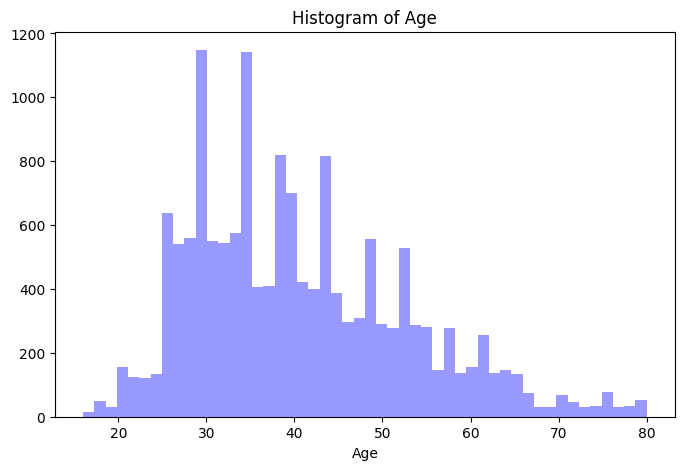

In [72]:
# Create a histogram of the Age column to look at the distribution
fig, ax = plt.subplots(figsize = (8, 5))
sns.distplot(data['Age'], kde= False, bins = 50, ax = ax , color = 'Blue')
ax.set(title = 'Histogram of Age', xlabel = 'Age')

The column Age is slightly right-skewed , thus there is a need to do a log transformation on the column Age to get a normal distribution later on.

[Text(0.5, 1.0, 'Boxplot of Age'), Text(0.5, 0, 'Age')]

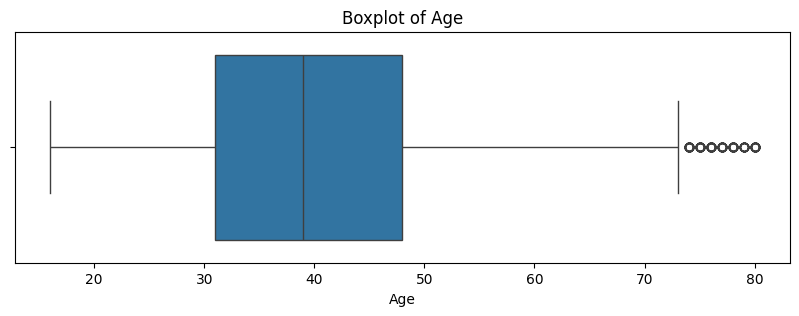

In [74]:
# Create a box plot to check if there are any outliers
fig, ax = plt.subplots(figsize = (10,3))
sns.boxplot( x = 'Age', data = data, ax = ax)
ax.set(title = 'Boxplot of Age', xlabel = 'Age')

There are only a few outliers , and might not be significant enough to affect the dataset as a whole. Hence, we will go ahead to do a log transformation on the Age column later on to take care of the distribution instead of removing the outliers form the dataset.

# Categorical features

In [75]:
# Lets retrieve the list of categorical features
categorical

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

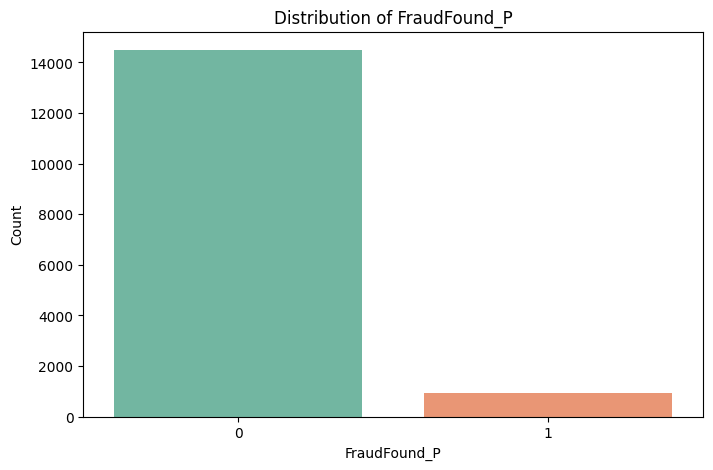

In [64]:
# Visualize the distribution of 'FraudFound_P'
plt.figure(figsize=(8, 5))
sns.countplot(x='FraudFound_P', data=data, palette='Set2')
plt.xlabel('FraudFound_P')
plt.ylabel('Count')
plt.title('Distribution of FraudFound_P')
plt.show()

The dataset is highly imbalanced